In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

# # # # # # # # # # # 
# tag = '2022042420_a05_2000n_train_32neigh_mindist0pt1'

# tag = '2022041804_04_2000n_test_32neigh_mindist0pt1'
# tag = '2022041804_04_12000n_extended_32neigh_mindist0pt1'
# tag = '2022041807_a03_2000n_test_32neigh_mindist0pt1'
# tag = '2022041807_a03_12000n_extended_32neigh_mindist0pt1'
tag = '2022041809_a04_2000n_test_32neigh_mindist0pt1'
# tag = '2022041809_a04_12000n_extended_32neigh_mindist0pt1'
# # # # # # # # # # # 

### Interactive plot.

In [2]:
import pandas as pd
from rdkit.Chem import PandasTools

df = pd.read_csv(f'/home/kat/Repos/SALSA/results/umap_dfs/{tag}.csv')
PandasTools.AddMoleculeColumnToFrame(df,'Smiles','Mol',includeFingerprints=False)
df = df[["Smiles","Mol","Label","Atype","x","y"]]
df_show = df[["Smiles","Label","Atype","x","y"]]

In [3]:
df_show[df_show.Label==1]

,Smiles,Label,Atype,x,y
1,O=C(Nc1cccc(C(F)(F)F)c1)c1nscc1NCCc1ccc2c(c1)OCO2,1,Anc,9.523054,8.084058
2005,CC(CNc1csnc1C(=O)Nc1cccc(C(F)(F)F)c1)c1ccc2c(c...,1,Aug,9.078169,7.480579
2006,Cc1cc2c(cc1CCNc1csnc1C(=O)Nc1cccc(C(F)(F)F)c1)...,1,Aug,11.882855,6.358105
2007,Cc1ccc(C(F)(F)F)cc1NC(=O)c1nscc1NCCc1ccc2c(c1)...,1,Aug,12.824008,6.372518
2008,Cc1snc(C(=O)Nc2cccc(C(F)(F)F)c2)c1NCCc1ccc2c(c...,1,Aug,10.023316,6.012612
2009,NN(CCc1ccc2c(c1)OCO2)c1csnc1C(=O)Nc1cccc(C(F)(...,1,Aug,9.109617,7.299044


In [37]:
%matplotlib inline
import plotly.graph_objs as go

from ipywidgets import Image, Layout, HBox, VBox
from rdkit.Chem import Draw
import PIL

import ipywidgets as widgets
import io

fc_idx = 11

# Assemble all the traces.
trace_anchors = (go.Scattergl(x=df[df.Atype=='Anc']['x'], 
                           y=df[df.Atype=='Anc']['y'], 
                           name='Anchors',
                           marker=dict(size=2, opacity=0.75, color='blue'),
                           hoverinfo='text',
                           text=df[df.Atype=='Anc']['Smiles'],
                           mode='markers'))
trace_augmentations = (go.Scattergl(x=df[df.Atype=='Aug']['x'], 
                           y=df[df.Atype=='Aug']['y'], 
                           name='Augmentations',
                           marker=dict(size=2, opacity=0.5, color='red'), #chartreuse
                           hoverinfo='text',
                           text=df[df.Atype=='Aug']['Smiles'],
                           mode='markers'))

trace_focus_b = (go.Scattergl(x=df[df.Label==fc_idx]['x'], 
                           y=df[df.Label==fc_idx]['y'], 
                           name='Focus',
                           marker=dict(size=10, opacity=1., color='black'), #chartreuse
                           hoverinfo='text',
                           text=df[df.Label==fc_idx]['Smiles'],
                           mode='markers'))

trace_focus_aug = (go.Scattergl(x=df[(df.Label==fc_idx) & (df.Atype=='Aug')]['x'], 
                           y=df[(df.Label==fc_idx)  & (df.Atype=='Aug')]['y'], 
                           name='Focus',
                           marker=dict(size=8, opacity=1., color='chartreuse'), #chartreuse
                           hoverinfo='text',
                           text=df[df.Label==fc_idx]['Smiles'],
                           mode='markers'))

trace_focus_anc = (go.Scattergl(x=df[(df.Label==fc_idx) & (df.Atype=='Anc')]['x'], 
                           y=df[(df.Label==fc_idx) & (df.Atype=='Anc')]['y'], 
                           name='Focus',
                           marker=dict(size=8, opacity=1., color='yellow'), #chartreuse
                           hoverinfo='text',
                           text=df[df.Label==fc_idx]['Smiles'],
                           mode='markers'))
data = [trace_augmentations, trace_anchors, trace_focus_b, trace_focus_aug, trace_focus_anc]
# data = [trace_augmentations, trace_anchors, ]

# Make figure.
fig = go.FigureWidget(data=data)
# fig.layout.hovermode = 'closest'
fig.update_layout(template='simple_white', autosize=False, height=512)
fig.update_yaxes(scaleanchor = "x", scaleratio = 1.)

# Show-mol-on-hover function.
# img = open('white.png','rb').read()
img = PIL.Image.new('1', (256, 256)).tobytes()
image_widget = Image(value=img)

def hover_fn(trace, points, state):
    
    if points.point_inds:
        if trace['name']=='Anchors':
            my_df = df[df.Atype=='Anc']
        elif trace['name']=='Augmentations':
            my_df = df[df.Atype=='Aug']
            
        idx = points.point_inds[0]
        datum = my_df.iloc[idx]
        mol = datum.Mol

        img = Draw.MolToImage(mol,size=(256, 512))  ### to make mol image smaller, alter first dim. 
        imgByteArr = io.BytesIO()
        img.save(imgByteArr, format='PNG')
        imgByteArr = imgByteArr.getvalue()
        image_widget.value = imgByteArr

for trace_num in range(len(fig.data)):
    fig.data[trace_num].on_hover(hover_fn)  
HBox([HBox([image_widget]),fig])

In [22]:
df_focus = df_show[df_show.Label==1]

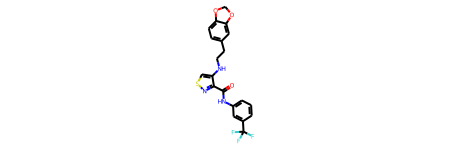

In [21]:
from rdkit.Chem import AllChem
from rdkit import Chem, Geometry
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import rdFMCS
from rdkit.Chem.Draw import rdDepictor
rdDepictor.SetPreferCoordGen(True)

Chem.MolFromSmiles('O=C(Nc1cccc(C(F)(F)F)c1)c1nscc1NCCc1ccc2c(c1)OCO2')

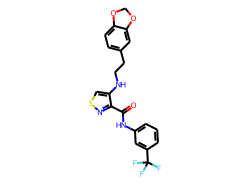

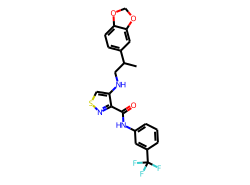

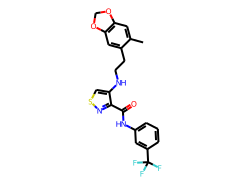

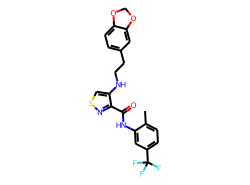

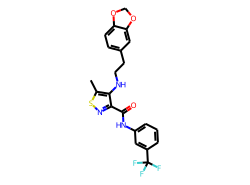

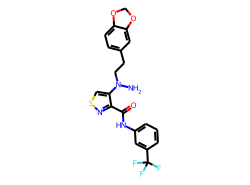

In [28]:

for row in df_focus.itertuples():
    mol = [Chem.MolFromSmiles(row.Smiles)]
    img = Draw.MolsToGridImage(mol, molsPerRow=1, subImgSize=(250, 185)) # 200, 150
    display(img)